<a href="https://colab.research.google.com/github/Pashokkkk/student_analyzer/blob/main/notebooks/SmartStudentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load and Inspect the Data**

In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("../student_performance_analyzer/student_data.csv")

# View the first 5 rows
print(df.head())

# Check the size and data types
print(df.shape)
print(df.info())


  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data c

**Clean the Data**

In [2]:
print(df.isnull().sum())


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


If only a few missing values, drop them:

df = df.dropna()

If many missing values, fill them:

df["study_time"].fillna(df["study_time"].mean(), inplace=True)

**Check and fix data types**

In [3]:
print(df.dtypes)
print(df.columns.tolist())

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'heal

Convert strings to numbers if needed:

df["final_score"] = pd.to_numeric(df["final_score"], errors="coerce")

Parse dates properly:

df["submission_date"] = pd.to_datetime(df["submission_date"])

**Drop or rename unnecessary columns**

In [4]:
df.drop(columns=["school"], inplace=True)
df.drop(columns=["Pstatus"], inplace=True)
df.drop(columns=["famsize"], inplace=True)
df.drop(columns=["address"], inplace=True)
df.drop(columns=["Mjob"], inplace=True)
df.drop(columns=["Fjob"], inplace=True)
df.drop(columns=["reason"], inplace=True)
df.drop(columns=["guardian"], inplace=True)
df.drop(columns=["nursery"], inplace=True)
df.drop(columns=["higher"], inplace=True)
df.drop(columns=["activities"], inplace=True)

df.rename(columns={"G3": "final_grade"}, inplace=True)


**Preliminary Analysis**

In [5]:
print(df.describe())
df["risk"] = df["final_grade"].apply(lambda x: 1 if x < 10 else 0)
print(df["risk"].value_counts())  # check class balance if applicable

              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   
std      0.896659    0.9988

**Save to SQLite**

In [6]:
import sqlite3

# Create or connect to a database
conn = sqlite3.connect("student_performance.db")

# Save the cleaned data to a table
df.to_sql("students", conn, if_exists="replace", index=False)

# Preview saved data
print(pd.read_sql("SELECT * FROM students LIMIT 5", conn))

# Close connection
conn.close()

  sex  age  Medu  Fedu  traveltime  studytime  failures schoolsup famsup paid  \
0   F   18     4     4           2          2         0       yes     no   no   
1   F   17     1     1           1          2         0        no    yes   no   
2   F   15     1     1           1          2         3       yes     no  yes   
3   F   15     4     2           1          3         0        no    yes  yes   
4   F   16     3     3           1          2         0        no    yes  yes   

   ... freetime goout  Dalc  Walc  health  absences  G1  G2  final_grade  risk  
0  ...        3     4     1     1       3         6   5   6            6     1  
1  ...        3     3     1     1       3         4   5   5            6     1  
2  ...        3     2     2     3       3        10   7   8           10     0  
3  ...        2     2     1     1       5         2  15  14           15     0  
4  ...        3     2     1     2       5         4   6  10           10     0  

[5 rows x 23 columns]


**download the file to your local machine**

In [7]:
from google.colab import files
files.download("student_performance.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ***Correlation Heatmap***

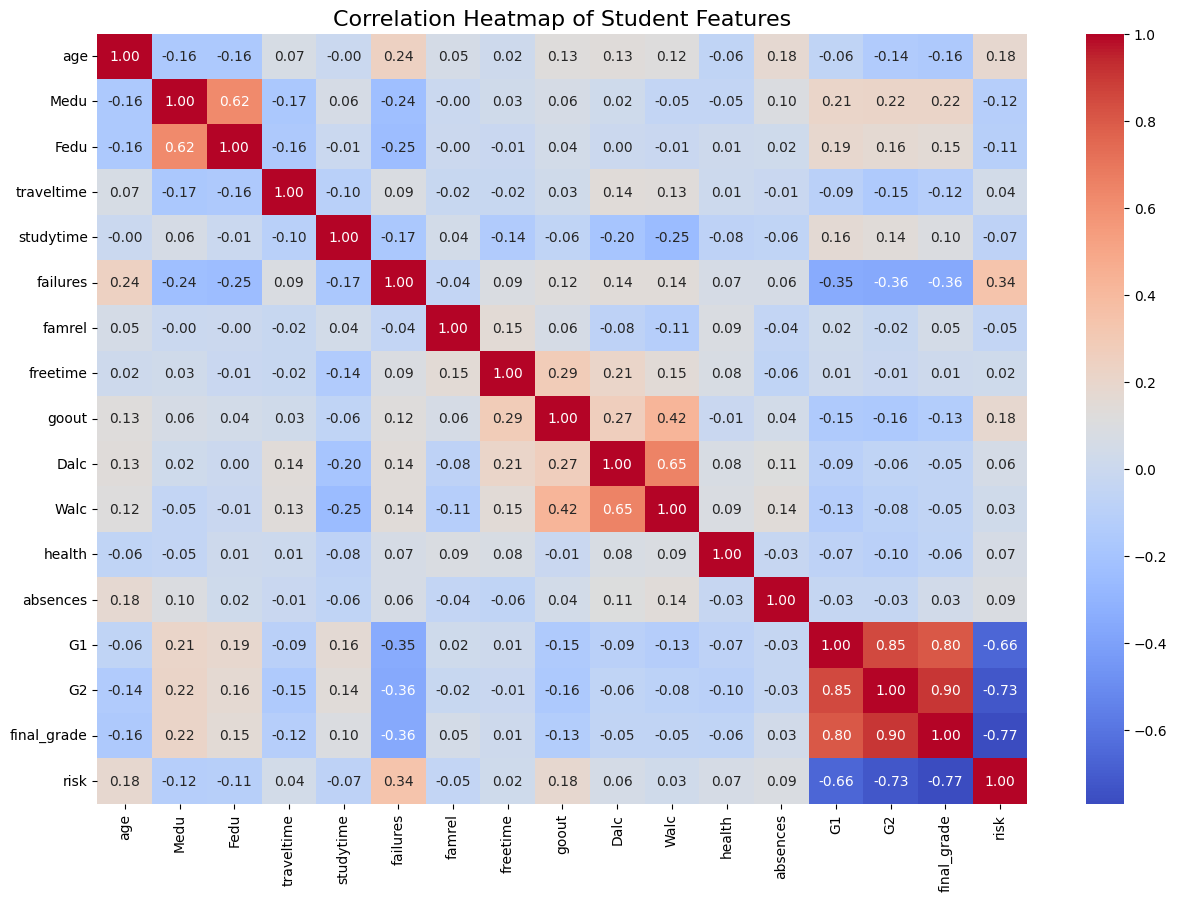

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot and save
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Student Features", fontsize=16)

# Save to file
plt.savefig("../plots/heatmap.png")

plt.show()
plt.close()


### **Histogram of final_grade**

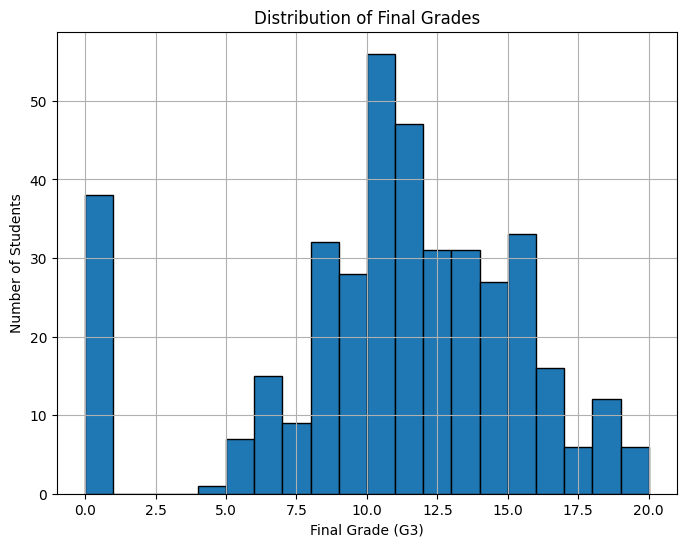

In [29]:
# Plot histogram of final grades
plt.figure(figsize=(8, 6))
plt.hist(df["final_grade"], bins=20, edgecolor="black")
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.grid(True)


# Save the figure
plt.savefig("../plots/final_grade_hist.png")

plt.show()
plt.close()


## Compare studytime, failures, absences between Risk Groups

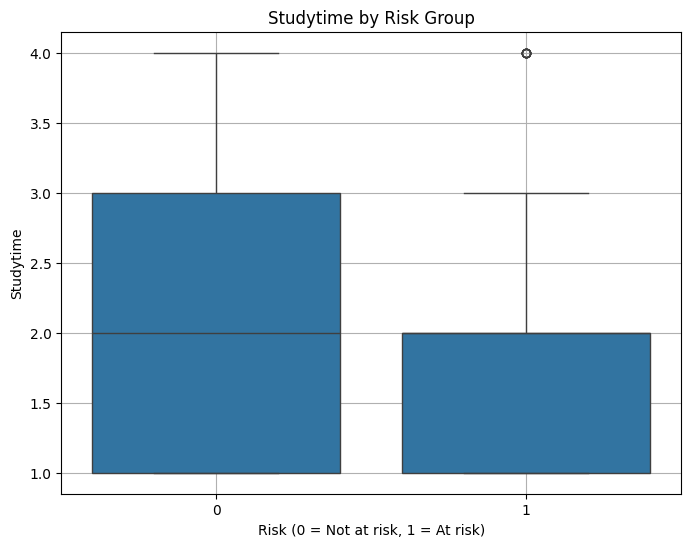

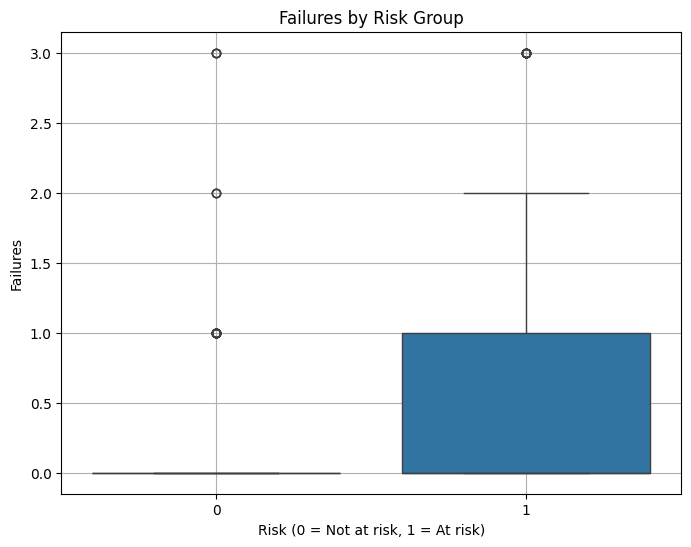

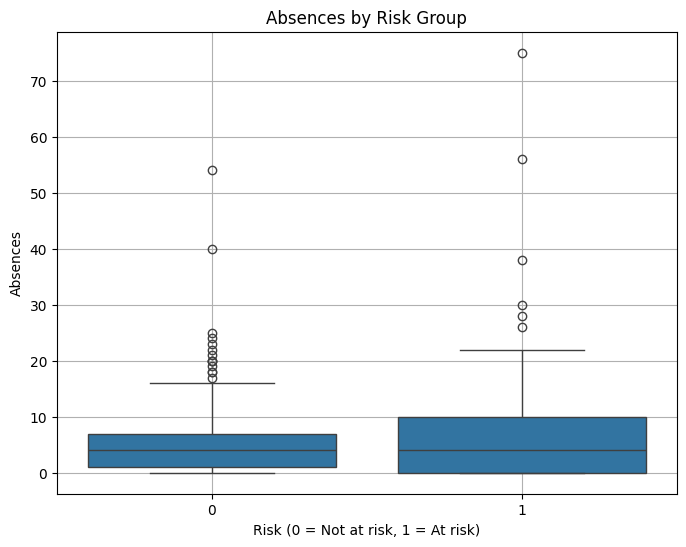

In [30]:
# Plot comparisons between risk groups
features_to_compare = ["studytime", "failures", "absences"]

for feature in features_to_compare:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="risk", y=feature, data=df)
    plt.title(f"{feature.capitalize()} by Risk Group")
    plt.xlabel("Risk (0 = Not at risk, 1 = At risk)")
    plt.ylabel(feature.capitalize())
    plt.grid(True)

    # Save each plot with a unique name
    filename = f"../plots/{feature}_by_risk.png"
    plt.savefig(filename)

    plt.show()
    plt.close()


## **Predicting Risk**
## **Split the Data into Training and Testing Sets**

In [12]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop(columns=["risk", "final_grade"])  # Drop target and final score
y = df["risk"]

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (316, 21)
Testing set size: (79, 21)


## **Encode Categorical Variables**

In [13]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid changing original
X_train = X_train.copy()
X_test = X_test.copy()

# Create label encoder
le = LabelEncoder()

# Find columns that are objects (strings)
categorical_cols = X_train.select_dtypes(include=["object"]).columns

# Encode them
for col in categorical_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print("Categorical columns encoded:", list(categorical_cols))


Categorical columns encoded: ['sex', 'schoolsup', 'famsup', 'paid', 'internet', 'romantic']


## **Train the Classification Model**

In [14]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

## **Evaluate the Model**

Accuracy: 0.9367088607594937
Precision: 0.8666666666666667
Recall: 0.9629629629629629

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95        52
           1       0.87      0.96      0.91        27

    accuracy                           0.94        79
   macro avg       0.92      0.94      0.93        79
weighted avg       0.94      0.94      0.94        79



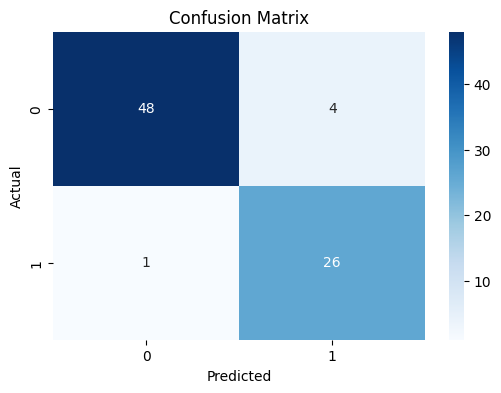

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# **Predicting Final Grade**
## **Select Features and Target**

In [16]:
# Define features (X) and target (y)
X = df.drop(columns=["final_grade", "risk"])  # Drop targets
y = df["final_grade"]


## **Split into Training and Testing Sets**

In [17]:
from sklearn.model_selection import train_test_split

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **Encode Categorical Variables (Again)**

In [18]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid overwriting
X_train = X_train.copy()
X_test = X_test.copy()

# Create label encoder
le = LabelEncoder()

# Find categorical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

# Encode them
for col in categorical_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])


## **Train the Regression Model**

In [19]:
from sklearn.linear_model import LinearRegression

# Create and train the model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)


LinearRegression()

## **Evaluate the Model**

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict
y_pred = reg_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")


Mean Absolute Error (MAE): 1.43
Root Mean Squared Error (RMSE): 2.19
R-squared (R²): 0.77


# **Save Model Predictions into SQLite**
## **Make predictions for all students**

In [21]:
# Make a copy of your full dataset
students_predictions = df.copy()

# Encode the categorical columns for prediction
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = students_predictions.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    students_predictions[col] = le.fit_transform(students_predictions[col])

# Predict risk
predicted_risk = model.predict(students_predictions.drop(columns=["final_grade", "risk"]))

# Predict final grade
predicted_final_grade = reg_model.predict(students_predictions.drop(columns=["final_grade", "risk"]))


## **Add Predictions as New Columns**

In [22]:
# Add predictions as new columns
students_predictions["predicted_risk"] = predicted_risk
students_predictions["predicted_final_grade"] = predicted_final_grade


## **Save to SQLite Database**

In [23]:
import sqlite3
import datetime

# Connect to your existing database
conn = sqlite3.connect("student_performance.db")

# Save the updated DataFrame to a new table (or overwrite the old one)
students_predictions.to_sql("students_predictions", conn, if_exists="replace", index=False)

# Add current date
students_predictions["prediction_date"] = datetime.datetime.now().strftime("%Y-%m-%d")

# Close connection
conn.close()


In [24]:
from google.colab import files
files.download("student_performance.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
conn = sqlite3.connect("student_performance.db")
df_query = pd.read_sql("SELECT * FROM students_predictions WHERE predicted_risk = 1", conn)
print(df_query)
# Close connection
conn.close()

     sex  age  Medu  Fedu  traveltime  studytime  failures  schoolsup  famsup  \
0      0   18     4     4           2          2         0          1       0   
1      0   17     1     1           1          2         0          0       1   
2      0   15     1     1           1          2         3          1       0   
3      0   17     4     4           2          2         0          1       1   
4      0   15     4     4           1          2         0          0       1   
..   ...  ...   ...   ...         ...        ...       ...        ...     ...   
126    0   18     3     1           1          2         0          0       1   
127    0   18     1     1           2          2         1          0       0   
128    1   20     2     2           1          2         2          0       1   
129    1   21     1     1           1          1         3          0       0   
130    1   19     1     1           1          1         0          0       0   

     paid  ...  Dalc  Walc 